In [5]:
import pandas as pd
import os

root = "."

# Sample decoys
df = pd.read_csv(os.path.join(root, "..", "output", "05_decoys", "eos3e6s_000.csv"))
rows = df.sample(n=5, random_state=24).reset_index(drop=True)
fixed_col = df.columns[1]
candidate_cols = df.columns[2:]  # excludes index 0 and index 1
random_cols = candidate_cols.to_series().sample(n=15, random_state=42).tolist()
selected_cols = [fixed_col] + random_cols
result = rows[selected_cols]

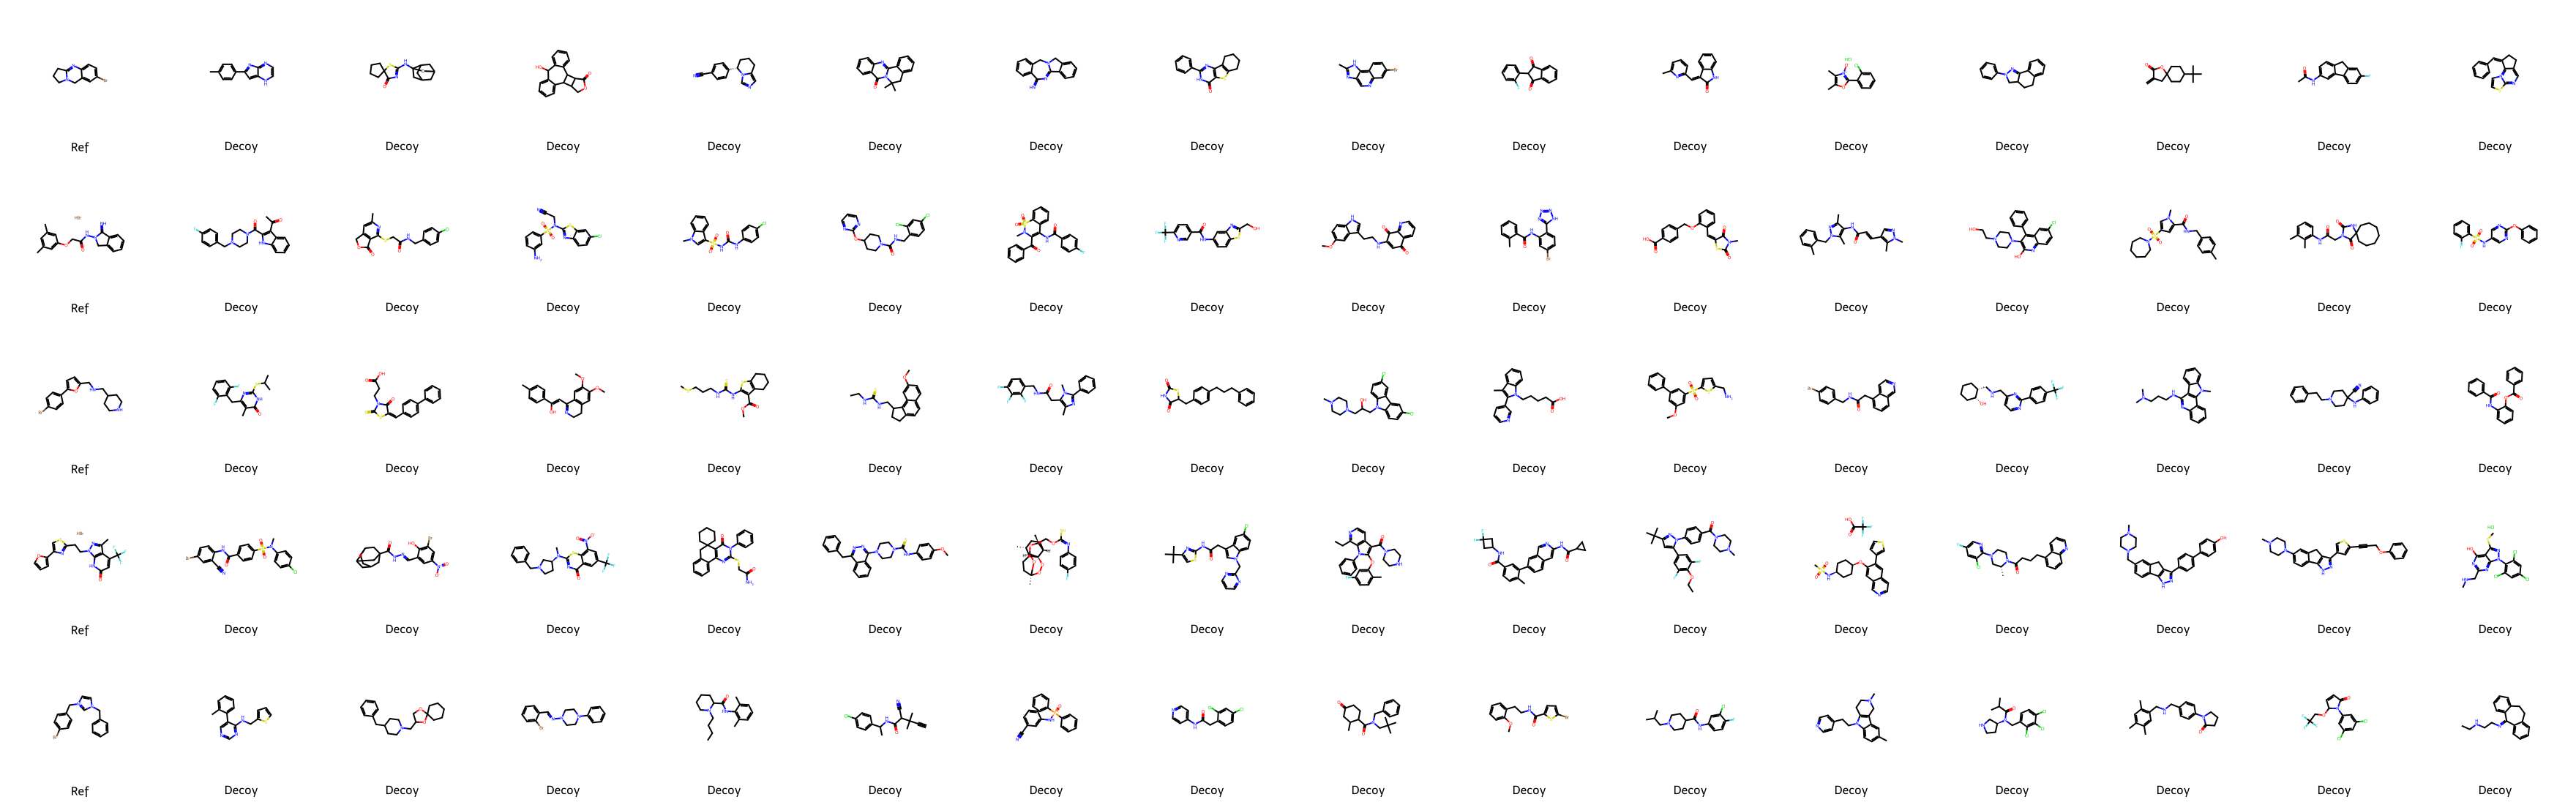

In [6]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

cols = result.columns.tolist()

mols = []
legends = []

for row_idx, row in result.iterrows():
    for col in cols:
        smi = row[col]
        mol = Chem.MolFromSmiles(str(smi)) if pd.notna(smi) else None
        mols.append(mol)
        if col == fixed_col:
            legends.append(f"Ref")
        else:
            legends.append(f"Decoy")

img = Draw.MolsToGridImage(
    mols,
    legends=legends,
    maxMols=1000,
    molsPerRow=len(cols),   # one dataframe row per image row
    subImgSize=(220, 220),
    useSVG=False
)

display(img)